In [1]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

np.random.seed(2137)
torch.manual_seed(2137)

In [2]:
housing = fetch_california_housing()

print(f"Data shape: {housing.data.shape}, Target shape: {housing.target.shape}")

print(f"Sample data: {housing.data[0:3]}")
print(f"Sample target: {housing.target[0:3]}")

Data shape: (20640, 8), Target shape: (20640,)
Sample data: [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]]
Sample target: [4.526 3.585 3.521]


In [3]:
X = torch.tensor(housing.data, dtype=torch.float32)
y = torch.tensor(housing.target, dtype=torch.float32).view(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2137)

mean = torch.mean(X_train, dim=0)
std = torch.std(X_train, dim=0)

def normalize(X, mean, std):
    return (X - mean) / std

X_train = normalize(X_train, mean, std)
X_test = normalize(X_test, mean, std)

N, d = housing.data.shape

In [4]:
W = torch.randn(d, 1)

b = torch.randn(1)

W.requires_grad = True
b.requires_grad = True

In [5]:
def forward(x):
    return x @ W + b

def loss(y, y_pred):
    return torch.mean((y - y_pred)**2) 

In [6]:
epochs = 500
lr = 0.01

train_losses = []
test_losses = []

for epoch in range(epochs):
    y_pred_train = forward(X_train)

    loss_train = loss(y_train, y_pred_train)
    train_losses.append(loss_train.item())

    loss_train.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        W.grad.zero_()
        b.grad.zero_()

    with torch.no_grad():
        y_pred_test = forward(X_test)
        loss_test = loss(y_test, y_pred_test)
        test_losses.append(loss_test.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss_train.item():.4f} | Test Loss: {loss_test.item():.4f}")

Epoch 10/500 | Train Loss: 13.8786 | Test Loss: 12.5238
Epoch 20/500 | Train Loss: 9.3147 | Test Loss: 8.4115
Epoch 30/500 | Train Loss: 6.5023 | Test Loss: 5.8979
Epoch 40/500 | Train Loss: 4.7283 | Test Loss: 4.3230
Epoch 50/500 | Train Loss: 3.5864 | Test Loss: 3.3142
Epoch 60/500 | Train Loss: 2.8379 | Test Loss: 2.6552
Epoch 70/500 | Train Loss: 2.3390 | Test Loss: 2.2164
Epoch 80/500 | Train Loss: 2.0008 | Test Loss: 1.9187
Epoch 90/500 | Train Loss: 1.7674 | Test Loss: 1.7126
Epoch 100/500 | Train Loss: 1.6030 | Test Loss: 1.5667
Epoch 110/500 | Train Loss: 1.4846 | Test Loss: 1.4607
Epoch 120/500 | Train Loss: 1.3969 | Test Loss: 1.3816
Epoch 130/500 | Train Loss: 1.3302 | Test Loss: 1.3207
Epoch 140/500 | Train Loss: 1.2776 | Test Loss: 1.2723
Epoch 150/500 | Train Loss: 1.2349 | Test Loss: 1.2326
Epoch 160/500 | Train Loss: 1.1992 | Test Loss: 1.1989
Epoch 170/500 | Train Loss: 1.1683 | Test Loss: 1.1696
Epoch 180/500 | Train Loss: 1.1410 | Test Loss: 1.1435
Epoch 190/500 | T

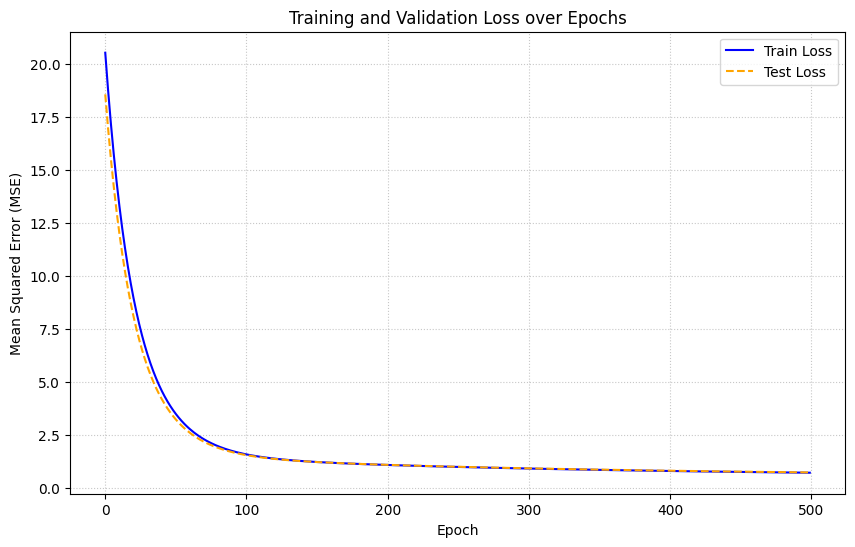

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='orange', linestyle='--')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

1. Why do we need torch.no_grad() during parameter update?
    * Nie chcemy żeby te obliczenia dostały się do grafu obliczeń, byłoby to nieporawne, a dodaktowo doprowadziło by do cyklu w grafie, który powinien być DAG'iem

2. Why must we reset gradients each iteration?
    * Każda iteracja ma kończy sie updatem, tamte gradietny byłby nieakutalne

3. Why does feature normalization typically help optimization?
    *  normalizacja zmniejsza "rozstrzał" wartość, bezpieczniejsze są obliczenia z perskeptywy numerycznej
